In [95]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns
import copy
import pickle
import shap
from models import *
from utilities import *
import warnings
warnings.filterwarnings('ignore')

In [96]:
##########################################################################################################

In [97]:
import tensorflow as tf

In [98]:
# shap.explainers._deep.deep_tf.op_handlers["AddV2"] = shap.explainers._deep.deep_tf.passthrough 
# shap.explainers._deep.deep_tf.op_handlers["FusedBatchNormV3"] = shap.explainers._deep.deep_tf.passthrough

In [99]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Nimbus Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [100]:
################### data import ###############

In [101]:
data_dir = '../results/data/'
data_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_dy_filter.pkl')
ba_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_ba_filter.pkl')
data_copy['Id_encoded'], uniques = pd.factorize(data_copy['SCCRIP_ID'])
data_copy = data_copy.fillna(0)
mapping_dict = {value: index for index, value in enumerate(uniques)}

In [102]:
hu = read_sas('../data/Apply_MI_Zheng_2023_01/hu.sas7bdat')

In [103]:
data_copy_nohu = data_copy[data_copy['HU_status']==0]
data_copy_hu = data_copy[data_copy['HU_status']!=0]

In [104]:
ba_copy['Id_encoded'] = ba_copy['SCCRIP_ID'].map(mapping_dict)
ba_copy = ba_copy[ba_copy['Id_encoded'].notna()]
ba_copy = ba_copy.drop_duplicates(subset='SCCRIP_ID', keep='last')
ba_copy.drop('SCCRIP_ID', inplace=True, axis=1)
ba_copy = ba_copy.fillna(0)

In [105]:
feature_dy = data_copy_nohu.drop(['HU_status','Id_encoded','SCCRIP_ID'],axis=1).columns
feature_ba = ba_copy.drop(['Id_encoded'], axis=1).columns

In [106]:
################ data process ##################

In [107]:
seq_length = 5

In [108]:
############ no-HU 

sequences, seq_ba, labels, date,  y_target = create_dataset(data_copy_nohu, ba_copy, seq_length, mapping_dict)
sequences_copy, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
X, y, X_bg, dt, ls, seq_map = create_sequences_with_background(sequences_copy, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
X_normalized, X_bg_normalized = normalize_X(X, X_bg)

(X_train_nohu,X_val_nohu,X_test_nohu,
            X_bg_train_nohu,X_bg_val_nohu,X_bg_test_nohu,
            dt_train_nohu, dt_val_nohu, dt_test_nohu, 
            y_train_nohu,y_val_nohu,y_test_nohu,
            ls_train_nohu, ls_val_nohu, ls_test_nohu,
            seq_map_train_nohu, seq_map_val_nohu, seq_map_test_nohu) = split_dataset(X_normalized, X_bg_normalized,dt, y, ls, seq_map)

In [109]:
############ HU 

sequences, seq_ba, labels, date,  y_target = create_dataset(data_copy_hu, ba_copy, seq_length, mapping_dict)
sequences_copy_h, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
X, y, X_bg, dt, ls, seq_map = create_sequences_with_background(sequences_copy_h, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
X_normalized, X_bg_normalized = normalize_X(X, X_bg)

(X_train_hu,X_val_hu,X_test_hu,
            X_bg_train_hu,X_bg_val_hu,X_bg_test_hu,
            dt_train_hu, dt_val_hu, dt_test_hu, 
            y_train_hu,y_val_hu,y_test_hu,
            ls_train_hu, ls_val_hu, ls_test_hu,
            seq_map_train_hu, seq_map_val_hu, seq_map_test_hu) = split_dataset(X_normalized, X_bg_normalized,dt, y, ls, seq_map)

In [110]:
# Initialize the model class
combined_model = CombinedLSTMModel(seq_length=seq_length, n_features=int(X_train_hu.shape[2]), bg_features=int(X_bg_train_hu.shape[2]))

Model input shapes: (None, 5, 786) (None, 1, 23) (None, 1, 1)
Model: "CombinedLSTMModel"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_bg (InputLayer)       [(None, 1, 23)]              0         []                            
                                                                                                  
 input_dt (InputLayer)       [(None, 1, 1)]               0         []                            
                                                                                                  
 input_seq (InputLayer)      [(None, 5, 786)]             0         []                            
                                                                                                  
 bg_plus_dt (Concatenate)    (None, 1, 24)                0         ['input_bg[0][0]',            
                    

In [111]:
# Train the model
history = combined_model.train(
    X_train_hu, X_bg_train_hu, dt_train_hu, y_train_hu,
    X_val_hu,   X_bg_val_hu,   dt_val_hu,   y_val_hu,
    epochs=20, batch_size=64,
    checkpoint_path="../results/models/T_best2.h5"
)

Epoch 1/20
203/206 [============================>.] - ETA: 0s - loss: 64.2537 - mean_absolute_error: 5.2137
Epoch 1: val_loss improved from inf to 21.10429, saving model to ../results/models/T_best2.h5
206/206 [==============================] - 7s 16ms/step - loss: 63.6214 - mean_absolute_error: 5.1833 - val_loss: 21.1043 - val_mean_absolute_error: 3.1369
Epoch 2/20
205/206 [============================>.] - ETA: 0s - loss: 13.6155 - mean_absolute_error: 2.6251
Epoch 2: val_loss improved from 21.10429 to 18.69630, saving model to ../results/models/T_best2.h5
206/206 [==============================] - 2s 12ms/step - loss: 13.6261 - mean_absolute_error: 2.6267 - val_loss: 18.6963 - val_mean_absolute_error: 3.0144
Epoch 3/20
202/206 [============================>.] - ETA: 0s - loss: 11.1969 - mean_absolute_error: 2.3768
Epoch 3: val_loss improved from 18.69630 to 15.16308, saving model to ../results/models/T_best2.h5
206/206 [==============================] - 2s 12ms/step - loss: 11.1478 

In [112]:
combined_model.save("../results/models/T_best2.h5")
combined_model.load("../results/models/T_best2.h5")

In [113]:
figure_dir = '../results/figures/tmodel/'
ensure_directory_exists(figure_dir)

Directory '../results/figures/tmodel/' already exists.


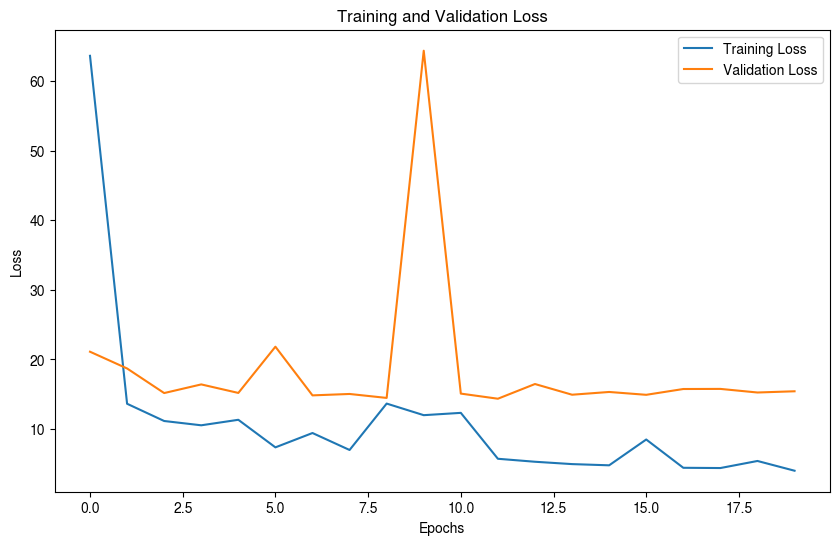

In [114]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# plt.savefig(figure_dir + 'LOSS.png')
plt.show()

In [115]:
y_pred_hu = combined_model.predict(X_test_hu, X_bg_test_hu, dt_test_hu)
y_pred_nohu = combined_model.predict(X_test_nohu, X_bg_test_nohu, dt_test_nohu)

38/38 [==============================] - 0s 2ms/step


In [116]:
def mae_np(y_pred, y_true):
    return np.mean(np.abs(y_pred - y_true))

def rmse_np(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true)**2))

In [117]:
from scipy.stats import pearsonr
mse = mean_squared_error(y_test_hu.flatten(), y_pred_hu.flatten())
mae = mean_absolute_error(y_test_hu.flatten(), y_pred_hu.flatten())
r2_hu = r2_score(y_test_hu.flatten(), y_pred_hu.flatten())
r_hu, _  = pearsonr(y_test_hu.flatten(), y_pred_hu.flatten())
mae2 = mae_np(y_test_hu.flatten(), y_pred_hu.flatten())
rmse = rmse_np(y_test_hu.flatten(), y_pred_hu.flatten())
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2_hu:.4f}")
print(f"r: {r_hu:.4f}")
print(f"mae: {mae2:.4f}")
print(f"rmse: {rmse:.4f}")

Mean Squared Error: 12.7599
Mean Absolute Error: 2.4217
R^2 Score: 0.8817
r: 0.9404
mae: 2.4217
rmse: 3.5721


In [118]:
mse = mean_squared_error(y_test_nohu.flatten(), y_pred_nohu.flatten())
mae = mean_absolute_error(y_test_nohu.flatten(), y_pred_nohu.flatten())
r2_nohu = r2_score(y_test_nohu.flatten(), y_pred_nohu.flatten())
r_nohu, _ = pearsonr(y_test_nohu.flatten(), y_pred_nohu.flatten())
mae2 = mae_np(y_test_nohu.flatten(), y_pred_nohu.flatten())
rmse = rmse_np(y_test_nohu.flatten(), y_pred_nohu.flatten())
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2_nohu:.4f}")
print(f"r: {r_nohu:.4f}")
print(f"mae: {mae2:.4f}")
print(f"rmse: {rmse:.4f}")

Mean Squared Error: 101.3179
Mean Absolute Error: 9.4288
R^2 Score: -0.7149
r: 0.8746
mae: 9.4288
rmse: 10.0657


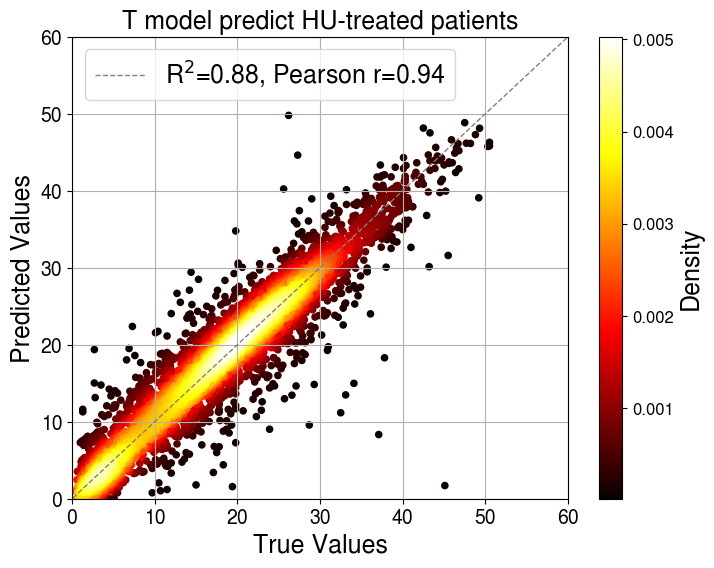

In [126]:
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom_grey", ["#B3B3B3", "#4D4D4D"])

from scipy.stats import gaussian_kde, linregress

y_test_hu = y_test_hu.reshape(y_test_hu.shape[0])
y_pred_hu = y_pred_hu.reshape(y_pred_hu.shape[0])
xy = np.vstack([y_test_hu, y_pred_hu])
xy = np.nan_to_num(xy)
z = gaussian_kde(xy)(xy)

# Sort the points by density (optional, for better visualization)
idx = z.argsort()
y_test_hu, y_pred_hu, z = y_test_hu[idx], y_pred_hu[idx], z[idx]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    y_test_hu,
    y_pred_hu,
    c=z,
    cmap='hot',   # or 'plasma', 'inferno', etc.
    s=20,
    edgecolor=None
)

x_line = np.linspace(y_test_hu.min(), y_test_hu.max(), 100)
plt.plot(x_line, x_line, linestyle='dashed', color='grey', linewidth=1,  label=f'R$^2$={r2_hu:.2f}, Pearson r={r_hu:.2f}')
plt.xlabel('True Values', fontsize=18)
plt.ylabel('Predicted Values',fontsize=18)
plt.xlim([0,60])
plt.ylim([0,60])
cbar = fig.colorbar(sc)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Density', fontsize=18)
ax.tick_params(labelsize=14)

plt.title('T model predict HU-treated patients', fontsize=18)
plt.legend(fontsize=18)
plt.grid(True)
plt.savefig(figure_dir+'dot_dot_hu3.pdf')

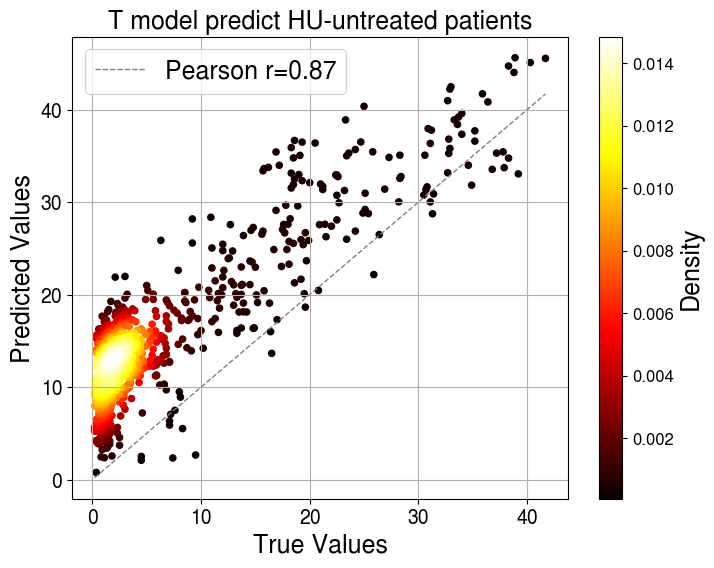

In [120]:
y_test_nohu = y_test_nohu.reshape(y_test_nohu.shape[0])
y_pred_nohu = y_pred_nohu.reshape(y_pred_nohu.shape[0])
xy = np.vstack([y_test_nohu, y_pred_nohu])
xy = np.nan_to_num(xy)
z = gaussian_kde(xy)(xy)

# Sort the points by density (optional, for better visualization)
idx = z.argsort()
y_test_nohu, y_pred_nohu, z = y_test_nohu[idx], y_pred_nohu[idx], z[idx]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    y_test_nohu,
    y_pred_nohu,
    c=z,
    cmap='hot',   # or 'plasma', 'inferno', etc.
    s=20,
    edgecolor=None
)

x_line = np.linspace(y_test_nohu.min(), y_test_nohu.max(), 100)
plt.plot(x_line, x_line, linestyle='dashed', color='grey', linewidth=1,  label=f'Pearson r={r_nohu:.2f}')
plt.xlabel('True Values', fontsize=18)
plt.ylabel('Predicted Values',fontsize=18)
# plt.xlim([0,80])
# plt.ylim([0,80])
cbar = fig.colorbar(sc)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Density', fontsize=18)
ax.tick_params(labelsize=14)

plt.title('T model predict HU-untreated patients', fontsize=18)
plt.legend(fontsize=18)
plt.grid(True)
plt.savefig(figure_dir+'dot_dot_nohu3.pdf')

In [121]:
####################################################

In [122]:
# Split predictions and true values
import random
y_test_split_hu = split_predictions_to_series(sequences_copy_h, seq_map_test_hu, y_test_hu, seq_length)
y_pred_split_hu = split_predictions_to_series(sequences_copy_h, seq_map_test_hu, y_pred_hu, seq_length)

i_list = []
for i, l in enumerate(y_test_split_hu):
    if len(l) >= 50:
        i_list.append(i)
v = random.choice(i_list)
# Example: Access the first time series predictions and true values
y_test_series_0 = y_test_split_hu[v]
y_pred_series_0 = y_pred_split_hu[v]

# Print shapes for verification
print(f"Original test series 0 shape: {y_test_series_0.shape}")
print(f"Predicted series 0 shape: {y_pred_series_0.shape}")

Original test series 0 shape: (55,)
Predicted series 0 shape: (55,)


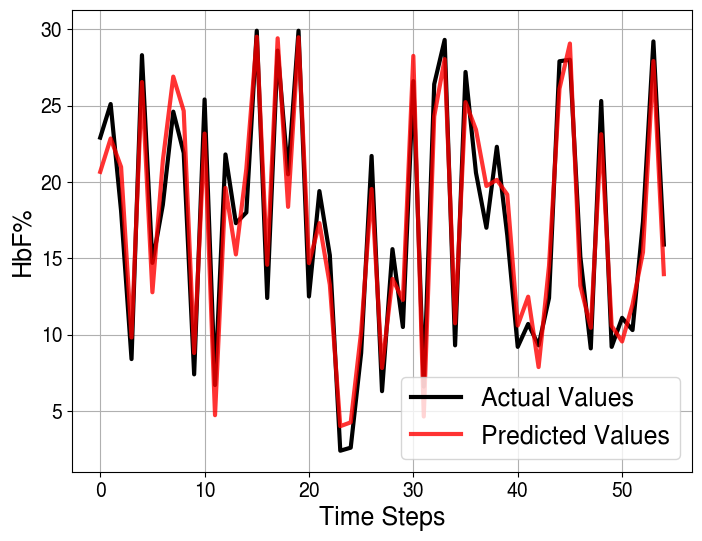

In [123]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(y_test_series_0.flatten(),lw=3, label='Actual Values', color='k')
plt.plot(y_pred_series_0.flatten(), lw=3, label='Predicted Values', color='red', alpha=0.8)
# plt.title('A patient example', fontsize=18)
plt.xlabel('Time Steps', fontsize=18)
plt.ylabel('HbF%', fontsize=18)
ax.tick_params(labelsize=14)
plt.legend(fontsize=18)
plt.grid()
# plt.savefig(figure_dir + 'example_hu2.pdf')
plt.show()

In [124]:
# Split predictions and true values
y_test_split_nohu = split_predictions_to_series(sequences_copy, seq_map_test_nohu, y_test_nohu, seq_length)
y_pred_split_nohu = split_predictions_to_series(sequences_copy, seq_map_test_nohu, y_pred_nohu, seq_length)

i_list = []
for i, l in enumerate(y_test_split_nohu):
    if len(l) >= 30:
        i_list.append(i)
v = random.choice(i_list)
# Example: Access the first time series predictions and true values
y_test_series_0 = y_test_split_nohu[v]
y_pred_series_0 = y_pred_split_nohu[v]
# Print shapes for verification
print(f"Original test series 0 shape: {y_test_series_0.shape}")
print(f"Predicted series 0 shape: {y_pred_series_0.shape}")

Original test series 0 shape: (117,)
Predicted series 0 shape: (117,)


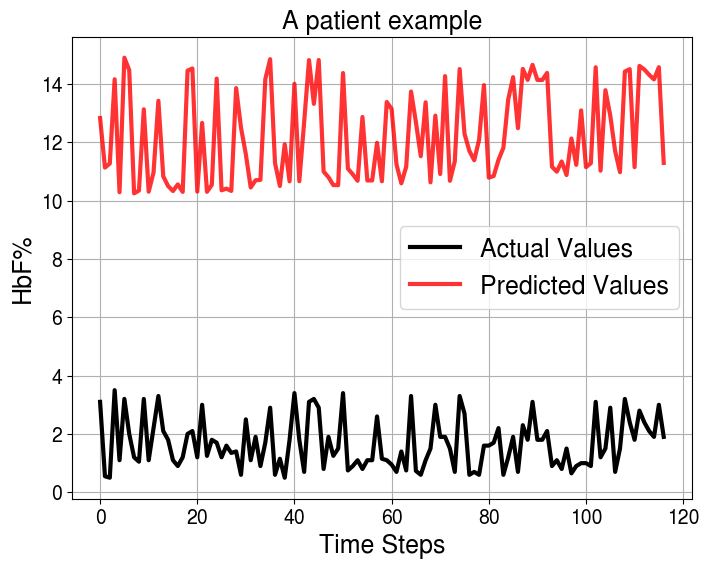

In [125]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(y_test_series_0.flatten(),lw=3, label='Actual Values', color='k')
plt.plot(y_pred_series_0.flatten(), lw=3, label='Predicted Values', color='red', alpha=0.8)
plt.title('A patient example', fontsize=18)
plt.xlabel('Time Steps', fontsize=18)
plt.ylabel('HbF%', fontsize=18)
ax.tick_params(labelsize=14)
plt.legend(fontsize=18)
plt.grid()
# plt.savefig(figure_dir + 'example_nohu2.pdf')
plt.show()